In [1]:
import os
import sys
CODE_PATH = "../../OneDrive - J. Craig Venter Institute/Documents/GitHub/frmatch"
sys.path.insert(0, os.path.abspath(CODE_PATH))
import FRmatch
CODE_PATH = "../../OneDrive - J. Craig Venter Institute/Documents/GitHub/nsforest"
sys.path.insert(0, os.path.abspath(CODE_PATH))
from nsforest import ns, nsforesting, utils, NSFOREST_VERSION
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import pickle
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 50)
folder = "tutorial_hlca_cellref"

In [2]:
# # file = f'../../Downloads/results_CellReftoHLCA_cell2cluster_fold1.pkl'
# file = f'tutorial_hlca_cellref/results_CellReftoHLCA_cell2cluster_fold1.pkl'
# with open(file, 'rb') as f: 
#     results_CellReftoHLCA_3 = pickle.load(f)
# print(results_CellReftoHLCA_3.keys())
# print(results_CellReftoHLCA_3["settings"])

In [3]:
results_CellReftoHLCA_3 = {"settings": {}, "results": pd.DataFrame()}
for fold in range(1, 11): 
    print(fold)
    with open(f'{folder}/results_CellReftoHLCA_cell2cluster_fold{fold}.pkl', 'rb') as f: 
        results_CellReftoHLCA_6 = pickle.load(f)
        results_CellReftoHLCA_3["results"] = pd.concat([results_CellReftoHLCA_3["results"], results_CellReftoHLCA_6["results"]])
print(results_CellReftoHLCA_3.keys())

1
2
3
4
5
6
7
8
9
10
dict_keys(['settings', 'results'])


In [4]:
order_hlca = ['Alveolar Mph MT-positive', 'Alveolar Mph CCL3+', 'Alveolar macrophages', 'Alveolar Mph proliferating', 
              'DC2', 'DC1', 'Migratory DCs', 'Classical monocytes', 'Non-classical monocytes', 'Monocyte-derived Mph', 
              'Interstitial Mph perivascular', 'Hematopoietic stem cells', 'Mast cells', 'T cells proliferating', 
              'NK cells', 'CD4 T cells', 'CD8 T cells', 'Plasma cells', 'B cells', 'Plasmacytoid DCs', 
              'Lymphatic EC mature', 'Lymphatic EC proliferating', 'Mesothelium', 'Adventitial fibroblasts', 
              'Subpleural fibroblasts', 'Peribronchial fibroblasts', 'Alveolar fibroblasts', 'Myofibroblasts', 
              'SM activated stress response', 'Pericytes', 'Smooth muscle', 'Smooth muscle FAM83D+', 'EC venous systemic', 
              'EC arterial', 'EC venous pulmonary', 'Lymphatic EC differentiating', 'EC aerocyte capillary', 
              'EC general capillary', 'Suprabasal', 'Hillock-like', 'Basal resting', 'Tuft', 'SMG mucous', 
              'SMG serous (nasal)', 'SMG serous (bronchial)', 'AT2', 'AT2 proliferating', 'AT0', 'pre-TB secretory', 
              'Club (nasal)', 'Goblet (nasal)', 'Goblet (bronchial)', 'Goblet (subsegmental)', 'Club (non-nasal)', 
              'SMG duct', 'AT1', 'Ionocyte', 'Neuroendocrine', 'Deuterosomal', 'Multiciliated (nasal)', 
              'Multiciliated (non-nasal)']
order_cellref = ['Alveolar macrophage', 'Classical DC subset 2', 'Classical DC subset 1', 'Mature DC subset', 
                 'Inflammatory monocyte', 'Patrolling monocyte', 'Interstitial macrophage', 
                 'Mast/Basophil', 'Innate lymphoid cell', 'Natural killer cell', 'CD4+ T cell', 'T regulatory cell', 
                 'CD8+ T cell', 'Plasma cell', 'B cell', 'Plasmacytoid DC', 'Lymphatic endothelial cell', 'Mesothelial cell', 
                 'Alveolar fibroblast 2', 'Alveolar fibroblast 1', 'Secondary crest myofibroblast', 'Pericyte', 
                 'Vascular smooth muscle cell', 'Airway smooth muscle cell', 'Systemic venous endothelial cell', 
                 'Arterial endothelial cell', 'Venous endothelial cell', 'Capillary 2 cell', 'Capillary 1 cell', 
                 'Basal cell', 'Suprabasal cell', 'Tuft cell', 'Mucous cell', 'Serous cell', 
                 'Alveolar type 2 cell', 'Respiratory airway secretory cell', 'Secretory cell', 'Goblet cell', 
                 'SMG Basal/Duct cell', 'Alveolar type 1 cell', 'Ionocyte', 'Pulmonary neuroendocrine cell', 
                 'Deuterosomal cell', 'Ciliated cell', 'Myoepithelial cell', 'Neutrophil', 'Megakaryocyte/Platelet', 
                 'Chondrocyte']

In [5]:
results_CellReftoHLCA = results_CellReftoHLCA_3["results"].copy()
results_CellReftoHLCA.columns.name = None
results_CellReftoHLCA.index.name = None
results_CellReftoHLCA = results_CellReftoHLCA.iloc[pd.Categorical(results_CellReftoHLCA.index, order_hlca).argsort()]
# results_CellReftoHLCA = results_CellReftoHLCA[order_cellref]
sorted_col_positions = pd.Categorical(results_CellReftoHLCA.columns, categories = order_cellref).argsort()
sorted_columns = results_CellReftoHLCA.columns[sorted_col_positions]
results_CellReftoHLCA = results_CellReftoHLCA.loc[:, sorted_columns]
results_CellReftoHLCA

,index,p_value,stat,runs_samp2,runs_samp1,runs,query_cluster,ref_cluster
0,EEM-scRNA-078_ATAGACCAGTTCGGTT,0.000016,-4.162510,1.0,1.0,2.0,Airway smooth muscle cell,AT0
1,D353_Biop_Int2_TGTTCCGGTCATCCCT-1-18,0.000016,-4.162510,1.0,1.0,2.0,Airway smooth muscle cell,AT0
2,P3_4_ATTACTCCAGCTGCTG,0.000093,-3.737321,1.0,2.0,3.0,Airway smooth muscle cell,AT0
3,P3_4_GGACAGAGTACAGCAG,0.000018,-4.135215,1.0,1.0,2.0,Airway smooth muscle cell,AT0
4,D354_Biop_Int2_TCATTACGTGGTCCGT-1-21,0.000016,-4.162510,1.0,1.0,2.0,Airway smooth muscle cell,AT0
...,...,...,...,...,...,...,...,...
472,EEM-scRNA-062_CCGATCTTCTGCGGAC,0.000014,-4.190353,1.0,1.0,2.0,Venous endothelial cell,pre-TB secretory
473,EEM-scRNA-062_CCGGTAGAGCAAGTGC,0.000015,-4.176362,1.0,1.0,2.0,Venous endothelial cell,pre-TB secretory
474,EEM-scRNA-062_CCGTAGGTCAGATGCT,0.000015,-4.176362,1.0,1.0,2.0,Venous endothelial cell,pre-TB secretory
475,EEM-scRNA-062_CGGGTGTCAGGAACCA,0.000014,-4.190353,1.0,1.0,2.0,Venous endothelial cell,pre-TB secretory


In [6]:
subset = results_CellReftoHLCA[results_CellReftoHLCA["query_cluster"] == "Airway smooth muscle cell"].sort_values("index")
subset = subset[subset["ref_cluster"].isin(["Smooth muscle FAM83D+", "Smooth muscle", "Myofibroblasts", "SM activated stress response"])]
subset[subset.duplicated(["index", "p_value"], keep = False)]
subset

,index,p_value,stat,runs_samp2,runs_samp1,runs,query_cluster,ref_cluster
37,AAAGAACCACGGAAGT-1_3,0.029520,-1.887892,1.0,6.0,7.0,Airway smooth muscle cell,Smooth muscle FAM83D+
37,AAAGAACCACGGAAGT-1_3,0.002385,-2.822124,1.0,4.0,5.0,Airway smooth muscle cell,SM activated stress response
37,AAAGAACCACGGAAGT-1_3,0.024349,-1.971222,1.0,6.0,7.0,Airway smooth muscle cell,Myofibroblasts
37,AAAGAACCACGGAAGT-1_3,0.008743,-2.376311,1.0,5.0,6.0,Airway smooth muscle cell,Smooth muscle
45,AAATGGACATTGTACG-1_5,0.002385,-2.822124,1.0,4.0,5.0,Airway smooth muscle cell,Myofibroblasts
...,...,...,...,...,...,...,...,...
36,TTGTGTTTCCATCAGA-1_1,0.000517,-3.281260,1.0,3.0,4.0,Airway smooth muscle cell,Smooth muscle
41,TTTGATCTCTTCACAT-1_3,0.170923,-0.950524,2.0,7.0,9.0,Airway smooth muscle cell,Smooth muscle FAM83D+
41,TTTGATCTCTTCACAT-1_3,0.000497,-3.292478,1.0,3.0,4.0,Airway smooth muscle cell,Myofibroblasts
41,TTTGATCTCTTCACAT-1_3,0.002244,-2.841654,3.0,2.0,5.0,Airway smooth muscle cell,Smooth muscle


In [7]:
# %%time
# FRmatch.plot_cell2cluster(results_CellReftoHLCA, width = 10, height = 10, prefix = ["HLCA_", "CellRef_"])

In [8]:
sig_level = 0.05
p_adj_method = "fdr_by"
prefix = ["HLCA_", "CellRef_"]
axis = 0
reorder = True
width = 10
height = 10
title = None

In [9]:
# Pivotting results to ref_cluster as index and query_cluster as columns
results = results_CellReftoHLCA.copy()
results = results.sort_values(["query_cluster", "index", "p_value"], ascending = [True, True, False])
results = results[~results.duplicated(["index", "query_cluster", "ref_cluster"], keep = "first")]
results = results.pivot(index = "ref_cluster", columns = ["query_cluster", "index"], values = "p_value").replace(np.nan, 0)
results.to_csv(f"{folder}/results_{p_adj_method}_{sig_level}.csv")
results

query_cluster                 Airway smooth muscle cell                       \
index                              AAAGAACCACGGAAGT-1_3 AAATGGACATTGTACG-1_5   
ref_cluster                                                                    
AT0                                            0.000016             0.000015   
AT1                                            0.000088             0.000016   
AT2                                            0.000016             0.000017   
AT2 proliferating                              0.000016             0.000088   
Adventitial fibroblasts                        0.000537             0.000098   
Alveolar Mph CCL3+                             0.000017             0.000017   
Alveolar Mph MT-positive                       0.000016             0.000016   
Alveolar Mph proliferating                     0.000016             0.000016   
Alveolar fibroblasts                           0.000098             0.000098   
Alveolar macrophages                           0.000017             0.000015   
B cells                                        0.000017             0.000016   
Basal resting                                  0.000093             0.000080   
CD4 T cells                                    0.000015             0.000016   
CD8 T cells                                    0.000084             0.000015   
Classical monocytes                            0.000016             0.000064   
Club (nasal)                                   0.000080             0.000076   
Club (non-nasal)                               0.000084             0.000093   
DC1                                            0.000016             0.000016   
DC2                                            0.000088             0.000016   
Deuterosomal                                   0.000084             0.000084   
EC aerocyte capillary                          0.000016             0.000016   
EC arterial                                    0.000084             0.000080   
EC general capillary                           0.000017             0.000016   
EC venous pulmonary                            0.000093             0.000084   
EC venous systemic                             0.000017             0.000016   
Goblet (bronchial)                             0.000017             0.000016   
Goblet (nasal)                                 0.000016             0.000016   
Goblet (subsegmental)                          0.000015             0.000016   
Hematopoietic stem cells                       0.000088             0.000016   
Hillock-like                                   0.000017             0.000015   
Interstitial Mph perivascular                  0.000015             0.000016   
Ionocyte                                       0.000093             0.000072   
Lymphatic EC differentiating                   0.000076             0.000014   
Lymphatic EC mature                            0.000093             0.000016   
Lymphatic EC proliferating                     0.000015             0.000015   
Mast cells                                     0.000016             0.000088   
Mesothelium                                    0.000016             0.000093   
Migratory DCs                                  0.000016             0.000017   
Monocyte-derived Mph                           0.000016             0.000016   
Multiciliated (nasal)                          0.000016             0.000015   
Multiciliated (non-nasal)                      0.000080             0.000016   
Myofibroblasts                                 0.024349             0.002385   
NK cells                                       0.000016             0.000016   
Neuroendocrine                                 0.000016             0.000017   
Non-classical monocytes                        0.000015             0.000017   
Peribronchial fibroblasts                      0.000080             0.000076   
Pericytes                                      0.000098             0.000098   


In [10]:
results_2 = FRmatch.padj_FRmatch(results, p_adj_method = p_adj_method)
results_2.to_csv(f"{folder}/results_2_{p_adj_method}_{sig_level}.csv")
results_2

query_cluster                 Airway smooth muscle cell                       \
index                              AAAGAACCACGGAAGT-1_3 AAATGGACATTGTACG-1_5   
ref_cluster                                                                    
AT0                                            0.000298             0.000287   
AT1                                            0.001597             0.000298   
AT2                                            0.000298             0.000316   
AT2 proliferating                              0.000298             0.001597   
Adventitial fibroblasts                        0.009517             0.001750   
Alveolar Mph CCL3+                             0.000316             0.000316   
Alveolar Mph MT-positive                       0.000298             0.000298   
Alveolar Mph proliferating                     0.000298             0.000298   
Alveolar fibroblasts                           0.001750             0.001750   
Alveolar macrophages                           0.000316             0.000287   
B cells                                        0.000316             0.000298   
Basal resting                                  0.001670             0.001464   
CD4 T cells                                    0.000287             0.000298   
CD8 T cells                                    0.001529             0.000287   
Classical monocytes                            0.000298             0.001207   
Club (nasal)                                   0.001464             0.001399   
Club (non-nasal)                               0.001529             0.001670   
DC1                                            0.000298             0.000298   
DC2                                            0.001597             0.000298   
Deuterosomal                                   0.001529             0.001529   
EC aerocyte capillary                          0.000298             0.000298   
EC arterial                                    0.001529             0.001464   
EC general capillary                           0.000316             0.000298   
EC venous pulmonary                            0.001670             0.001529   
EC venous systemic                             0.000316             0.000298   
Goblet (bronchial)                             0.000316             0.000298   
Goblet (nasal)                                 0.000298             0.000298   
Goblet (subsegmental)                          0.000287             0.000298   
Hematopoietic stem cells                       0.001597             0.000298   
Hillock-like                                   0.000316             0.000287   
Interstitial Mph perivascular                  0.000287             0.000298   
Ionocyte                                       0.001670             0.001335   
Lymphatic EC differentiating                   0.001399             0.000287   
Lymphatic EC mature                            0.001670             0.000298   
Lymphatic EC proliferating                     0.000287             0.000287   
Mast cells                                     0.000298             0.001597   
Mesothelium                                    0.000298             0.001670   
Migratory DCs                                  0.000298             0.000316   
Monocyte-derived Mph                           0.000298             0.000298   
Multiciliated (nasal)                          0.000298             0.000287   
Multiciliated (non-nasal)                      0.001464             0.000298   
Myofibroblasts                                 0.427949             0.042069   
NK cells                                       0.000298             0.000298   
Neuroendocrine                                 0.000298             0.000316   
Non-classical monocytes                        0.000287             0.000316   
Peribronchial fibroblasts                      0.001464             0.001399   
Pericytes                                      0.001750             0.001750   


In [11]:
# Setting values to zero unless passes sig_level threshold
results_3 = results_2.applymap(lambda x: x if x > sig_level else 0)
results_3.to_csv(f"{folder}/results_3_{p_adj_method}_{sig_level}.csv")
results_3

query_cluster                 Airway smooth muscle cell                       \
index                              AAAGAACCACGGAAGT-1_3 AAATGGACATTGTACG-1_5   
ref_cluster                                                                    
AT0                                            0.000000                  0.0   
AT1                                            0.000000                  0.0   
AT2                                            0.000000                  0.0   
AT2 proliferating                              0.000000                  0.0   
Adventitial fibroblasts                        0.000000                  0.0   
Alveolar Mph CCL3+                             0.000000                  0.0   
Alveolar Mph MT-positive                       0.000000                  0.0   
Alveolar Mph proliferating                     0.000000                  0.0   
Alveolar fibroblasts                           0.000000                  0.0   
Alveolar macrophages                           0.000000                  0.0   
B cells                                        0.000000                  0.0   
Basal resting                                  0.000000                  0.0   
CD4 T cells                                    0.000000                  0.0   
CD8 T cells                                    0.000000                  0.0   
Classical monocytes                            0.000000                  0.0   
Club (nasal)                                   0.000000                  0.0   
Club (non-nasal)                               0.000000                  0.0   
DC1                                            0.000000                  0.0   
DC2                                            0.000000                  0.0   
Deuterosomal                                   0.000000                  0.0   
EC aerocyte capillary                          0.000000                  0.0   
EC arterial                                    0.000000                  0.0   
EC general capillary                           0.000000                  0.0   
EC venous pulmonary                            0.000000                  0.0   
EC venous systemic                             0.000000                  0.0   
Goblet (bronchial)                             0.000000                  0.0   
Goblet (nasal)                                 0.000000                  0.0   
Goblet (subsegmental)                          0.000000                  0.0   
Hematopoietic stem cells                       0.000000                  0.0   
Hillock-like                                   0.000000                  0.0   
Interstitial Mph perivascular                  0.000000                  0.0   
Ionocyte                                       0.000000                  0.0   
Lymphatic EC differentiating                   0.000000                  0.0   
Lymphatic EC mature                            0.000000                  0.0   
Lymphatic EC proliferating                     0.000000                  0.0   
Mast cells                                     0.000000                  0.0   
Mesothelium                                    0.000000                  0.0   
Migratory DCs                                  0.000000                  0.0   
Monocyte-derived Mph                           0.000000                  0.0   
Multiciliated (nasal)                          0.000000                  0.0   
Multiciliated (non-nasal)                      0.000000                  0.0   
Myofibroblasts                                 0.427949                  0.0   
NK cells                                       0.000000                  0.0   
Neuroendocrine                                 0.000000                  0.0   
Non-classical monocytes                        0.000000                  0.0   
Peribronchial fibroblasts                      0.000000                  0.0   
Pericytes                                      0.000000                  0.0   


In [12]:
# Samples with col sum = 0 are labeled as 'unassigned'
results_3.sum()

query_cluster              index               
Airway smooth muscle cell  AAAGAACCACGGAAGT-1_3    1.099748
                           AAATGGACATTGTACG-1_5    1.000000
                           AACCTTTTCCTCTCTT-1_2    1.000000
                           AAGCATCGTCGTCTCT-1_3    1.167808
                           AAGCCATCAAGTCCCG-1_5    1.000000
                                                     ...   
Venous endothelial cell    TTGTGGAAGGCTCCCA-1_3    1.000000
                           TTGTTGTGTAATGCTC-1_2    1.000000
                           TTTACTGTCTGGCCTT-1_7    1.000000
                           TTTCACAGTTCAAGTC-1_5    1.000000
                           TTTCAGTGTCAGACTT-1_5    1.000000
Length: 347836, dtype: float64

In [13]:
# Adding the unassigned row
samples = results_3.columns[results_3.sum() == 0]
temp = pd.DataFrame(dict(zip(samples, [1] * len(samples))), index = ["unassigned"])
if temp.shape[1] != 0: 
    temp.columns.names = ["query_cluster", "index"]
    temp.index.name = "ref_cluster"
    results_4 = pd.concat([results_3, temp])
    results_4.to_csv(f"{folder}/results_4_{p_adj_method}_{sig_level}.csv")
else: 
    results_4 = results_3.copy()
results_4

query_cluster                 Airway smooth muscle cell                       \
index                              AAAGAACCACGGAAGT-1_3 AAATGGACATTGTACG-1_5   
ref_cluster                                                                    
AT0                                            0.000000                  0.0   
AT1                                            0.000000                  0.0   
AT2                                            0.000000                  0.0   
AT2 proliferating                              0.000000                  0.0   
Adventitial fibroblasts                        0.000000                  0.0   
Alveolar Mph CCL3+                             0.000000                  0.0   
Alveolar Mph MT-positive                       0.000000                  0.0   
Alveolar Mph proliferating                     0.000000                  0.0   
Alveolar fibroblasts                           0.000000                  0.0   
Alveolar macrophages                           0.000000                  0.0   
B cells                                        0.000000                  0.0   
Basal resting                                  0.000000                  0.0   
CD4 T cells                                    0.000000                  0.0   
CD8 T cells                                    0.000000                  0.0   
Classical monocytes                            0.000000                  0.0   
Club (nasal)                                   0.000000                  0.0   
Club (non-nasal)                               0.000000                  0.0   
DC1                                            0.000000                  0.0   
DC2                                            0.000000                  0.0   
Deuterosomal                                   0.000000                  0.0   
EC aerocyte capillary                          0.000000                  0.0   
EC arterial                                    0.000000                  0.0   
EC general capillary                           0.000000                  0.0   
EC venous pulmonary                            0.000000                  0.0   
EC venous systemic                             0.000000                  0.0   
Goblet (bronchial)                             0.000000                  0.0   
Goblet (nasal)                                 0.000000                  0.0   
Goblet (subsegmental)                          0.000000                  0.0   
Hematopoietic stem cells                       0.000000                  0.0   
Hillock-like                                   0.000000                  0.0   
Interstitial Mph perivascular                  0.000000                  0.0   
Ionocyte                                       0.000000                  0.0   
Lymphatic EC differentiating                   0.000000                  0.0   
Lymphatic EC mature                            0.000000                  0.0   
Lymphatic EC proliferating                     0.000000                  0.0   
Mast cells                                     0.000000                  0.0   
Mesothelium                                    0.000000                  0.0   
Migratory DCs                                  0.000000                  0.0   
Monocyte-derived Mph                           0.000000                  0.0   
Multiciliated (nasal)                          0.000000                  0.0   
Multiciliated (non-nasal)                      0.000000                  0.0   
Myofibroblasts                                 0.427949                  0.0   
NK cells                                       0.000000                  0.0   
Neuroendocrine                                 0.000000                  0.0   
Non-classical monocytes                        0.000000                  0.0   
Peribronchial fibroblasts                      0.000000                  0.0   
Pericytes                                      0.000000                  0.0   


In [14]:
results_4.idxmax()

query_cluster              index               
Airway smooth muscle cell  AAAGAACCACGGAAGT-1_3    Smooth muscle FAM83D+
                           AAATGGACATTGTACG-1_5    Smooth muscle FAM83D+
                           AACCTTTTCCTCTCTT-1_2    Smooth muscle FAM83D+
                           AAGCATCGTCGTCTCT-1_3    Smooth muscle FAM83D+
                           AAGCCATCAAGTCCCG-1_5    Smooth muscle FAM83D+
                                                           ...          
Venous endothelial cell    TTGTGGAAGGCTCCCA-1_3      EC venous pulmonary
                           TTGTTGTGTAATGCTC-1_2      EC venous pulmonary
                           TTTACTGTCTGGCCTT-1_7      EC venous pulmonary
                           TTTCACAGTTCAAGTC-1_5      EC venous pulmonary
                           TTTCAGTGTCAGACTT-1_5      EC venous pulmonary
Length: 347836, dtype: object

In [15]:
# idxmax: returns ref_cluster with largest value per sample
results_5 = pd.DataFrame(results_4.idxmax()).reset_index().rename(columns = {0: "ref_cluster"})
results_5 = pd.DataFrame(results_5.value_counts(["query_cluster", "ref_cluster"])).reset_index()
results_5 = results_5.pivot(index='ref_cluster', columns='query_cluster')
results_5.to_csv(f"{folder}/results_5_{p_adj_method}_{sig_level}.csv")
results_5

0                        \
query_cluster                 Airway smooth muscle cell Alveolar fibroblast 1   
ref_cluster                                                                     
AT0                                                 NaN                   NaN   
AT1                                                 NaN                   NaN   
AT2                                                 NaN                   NaN   
AT2 proliferating                                   NaN                   NaN   
Adventitial fibroblasts                             NaN                   NaN   
Alveolar Mph CCL3+                                  NaN                   NaN   
Alveolar Mph proliferating                          NaN                   NaN   
Alveolar fibroblasts                                NaN                5445.0   
Alveolar macrophages                                NaN                   NaN   
B cells                                             NaN                   NaN   
Basal resting                                       NaN                   NaN   
CD4 T cells                                         NaN                   NaN   
CD8 T cells                                         NaN                   NaN   
Classical monocytes                                 NaN                   NaN   
Club (non-nasal)                                    NaN                   NaN   
DC1                                                 NaN                   NaN   
DC2                                                 NaN                   NaN   
Deuterosomal                                        NaN                   NaN   
EC aerocyte capillary                               NaN                   NaN   
EC arterial                                         NaN                   NaN   
EC general capillary                                NaN                   NaN   
EC venous pulmonary                                 NaN                   NaN   
EC venous systemic                                  NaN                   NaN   
Goblet (bronchial)                                  NaN                   NaN   
Goblet (subsegmental)                               NaN                   NaN   
Interstitial Mph perivascular                       NaN                   NaN   
Ionocyte                                            NaN                   NaN   
Lymphatic EC differentiating                        NaN                   NaN   
Lymphatic EC mature                                 NaN                   NaN   
Mast cells                                          NaN                   NaN   
Mesothelium                                         NaN                   NaN   
Migratory DCs                                       NaN                   NaN   
Monocyte-derived Mph                                NaN                   NaN   
Multiciliated (nasal)                               NaN                   NaN   
Multiciliated (non-nasal)                           NaN                   NaN   
Myofibroblasts                                      NaN                   NaN   
NK cells                                            NaN                   NaN   
Neuroendocrine                                      NaN                   NaN   
Non-classical monocytes                             NaN                   NaN   
Pericytes                                           NaN                   NaN   
Plasma cells                                        NaN                   NaN   
Plasmacytoid DCs                                    NaN                   NaN   
SM activated stress response                        NaN                   NaN   
SMG duct                                            NaN                   NaN   
SMG mucous                                          NaN                   NaN   
SMG serous (bronchial)                              NaN                   NaN   
Smooth muscle                                       NaN                   NaN   
Smoo

In [16]:
results_6 = results_5.replace(np.nan, 0)
results_6.columns = [val[1] for val in results_6.columns]
results_6.columns.name = "query_cluster"
if reorder: 
    # ensuring unassigned row is at the bottom
    unassigned = results_6.loc[results_6.index == 'unassigned'].copy()
    results_6 = results_6.loc[results_6.index != 'unassigned'].copy()
    results_6 = FRmatch.reorder_FRmatch(results_6, axis = axis)
    results_6 = pd.concat([results_6, unassigned])
results_6.to_csv(f"{folder}/results_6_{p_adj_method}_{sig_level}.csv")
results_6

query_cluster,Airway smooth muscle cell,Alveolar fibroblast 1,Alveolar fibroblast 2,Alveolar macrophage,Alveolar type 1 cell,Alveolar type 2 cell,Arterial endothelial cell,B cell,Basal cell,CD4+ T cell,CD8+ T cell,Capillary 1 cell,Capillary 2 cell,Ciliated cell,Classical DC subset 1,Classical DC subset 2,Deuterosomal cell,Goblet cell,Inflammatory monocyte,Innate lymphoid cell,Interstitial macrophage,Ionocyte,Lymphatic endothelial cell,Mast/Basophil,Mature DC subset,Megakaryocyte/Platelet,Mesothelial cell,Mucous cell,Myoepithelial cell,Natural killer cell,Neutrophil,Patrolling monocyte,Pericyte,Plasma cell,Plasmacytoid DC,Pulmonary neuroendocrine cell,Respiratory airway secretory cell,SMG Basal/Duct cell,Secondary crest myofibroblast,Secretory cell,Serous cell,Suprabasal cell,Systemic venous endothelial cell,T regulatory cell,Vascular smooth muscle cell,Venous endothelial cell
ref_cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Smooth muscle FAM83D+,515.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Alveolar fibroblasts,0.0,5445.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Adventitial fibroblasts,0.0,0.0,2670.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Alveolar macrophages,0.0,0.0,0.0,21038.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Alveolar Mph CCL3+,0.0,0.0,0.0,4938.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Alveolar Mph proliferating,0.0,0.0,0.0,467.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Monocyte-derived Mph,0.0,0.0,0.0,13.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,86.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AT1,0.0,0.0,0.0,0.0,11131.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
AT2,0.0,0.0,0.0,0.0,0.0,14131.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [17]:
results_7 = pd.DataFrame(columns = ["match", "query_cluster", "Prop"]) # ref_cluster, query_cluster, proportion
for index, row in results_6.iterrows(): 
    for col in results_6.columns: 
        if sum(results_6[col]) == 0: value = 0
        else: value = row[col] / sum(results_6[col])
        results_7 = pd.concat([results_7, pd.DataFrame(dict(zip(results_7.columns, [index, col, value])), index = [0])])

if not reorder and len(order_query) != 0: 
    # query cluster order
    results_7["query_cluster"] = results_7["query_cluster"].astype("category")
    results_7["query_cluster"] = results_7["query_cluster"].cat.set_categories(order_query)
if not reorder and len(order_ref) != 0: 
    # reference cluster order
    results_7["match"] = results_7["match"].astype("category")
    results_7["match"] = results_7["match"].cat.set_categories(order_ref)
    results_7 = results_7.sort_values(["match", "query_cluster"])
results_7["match"] = [prefix[0] + val for val in results_7["match"]]
results_7["query_cluster"] = [prefix[1] + val for val in results_7["query_cluster"]]
results_7.to_csv(f"{folder}/results_7_{p_adj_method}_{sig_level}.csv")
results_7

,match,query_cluster,Prop
0,HLCA_Smooth muscle FAM83D+,CellRef_Airway smooth muscle cell,1.000000
0,HLCA_Smooth muscle FAM83D+,CellRef_Alveolar fibroblast 1,0.000000
0,HLCA_Smooth muscle FAM83D+,CellRef_Alveolar fibroblast 2,0.000000
0,HLCA_Smooth muscle FAM83D+,CellRef_Alveolar macrophage,0.000000
0,HLCA_Smooth muscle FAM83D+,CellRef_Alveolar type 1 cell,0.000000
...,...,...,...
0,HLCA_unassigned,CellRef_Suprabasal cell,0.154262
0,HLCA_unassigned,CellRef_Systemic venous endothelial cell,0.000000
0,HLCA_unassigned,CellRef_T regulatory cell,0.000000
0,HLCA_unassigned,CellRef_Vascular smooth muscle cell,0.000000


In [18]:
results_7 = pd.read_csv("tutorial_hlca_cellref/results_7_fdr_by_0.05.csv", index_col = 0)
results_7

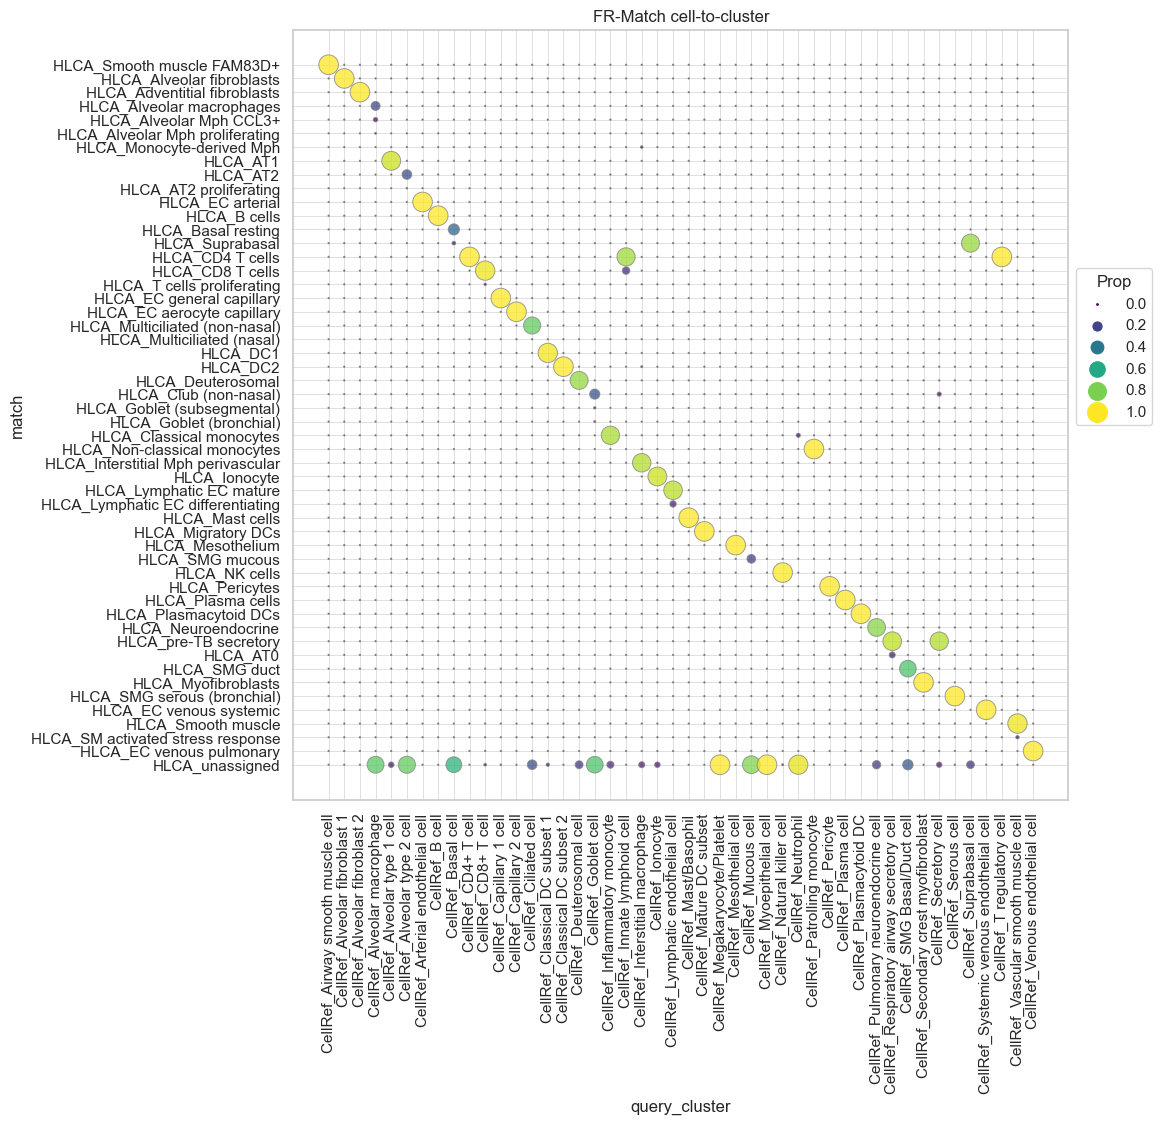

In [20]:
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import matplotlib.patches as mpatches
if not title: title = "FR-Match cell-to-cluster"
fig, (ax1) = plt.subplots(1, 1, figsize=(width, height))
sns.set_theme(style="whitegrid", rc={"grid.color": "lightgray", "grid.linewidth": 0.5})
ax = sns.scatterplot(results_7, x = "query_cluster", y = "match", hue = "Prop", size = "Prop", 
                    hue_norm = (0, 1), size_norm = (0, 1), legend = "brief", 
                    sizes = (1, 200), alpha = 0.75, linewidth = 0.7, edgecolor = "gray", 
                    palette = sns.color_palette("viridis", as_cmap=True), 
                   )
a = plt.title(title)
a = plt.xticks(rotation = 90)
a = plt.legend(title = "Prop", bbox_to_anchor = (1.0, 0.7))

In [21]:
results_7 = pd.read_csv("tutorial_hlca_cellref/results_7_fdr_bh_0.1.csv", index_col = 0)
results_7

,match,query_cluster,Prop
0,HLCA_Smooth muscle FAM83D+,CellRef_Airway smooth muscle cell,0.786408
0,HLCA_Smooth muscle FAM83D+,CellRef_Alveolar fibroblast 1,0.000000
0,HLCA_Smooth muscle FAM83D+,CellRef_Alveolar fibroblast 2,0.000000
0,HLCA_Smooth muscle FAM83D+,CellRef_Alveolar macrophage,0.000000
0,HLCA_Smooth muscle FAM83D+,CellRef_Alveolar type 1 cell,0.000000
...,...,...,...
0,HLCA_unassigned,CellRef_Suprabasal cell,0.871176
0,HLCA_unassigned,CellRef_Systemic venous endothelial cell,0.039922
0,HLCA_unassigned,CellRef_T regulatory cell,0.424603
0,HLCA_unassigned,CellRef_Vascular smooth muscle cell,0.389918


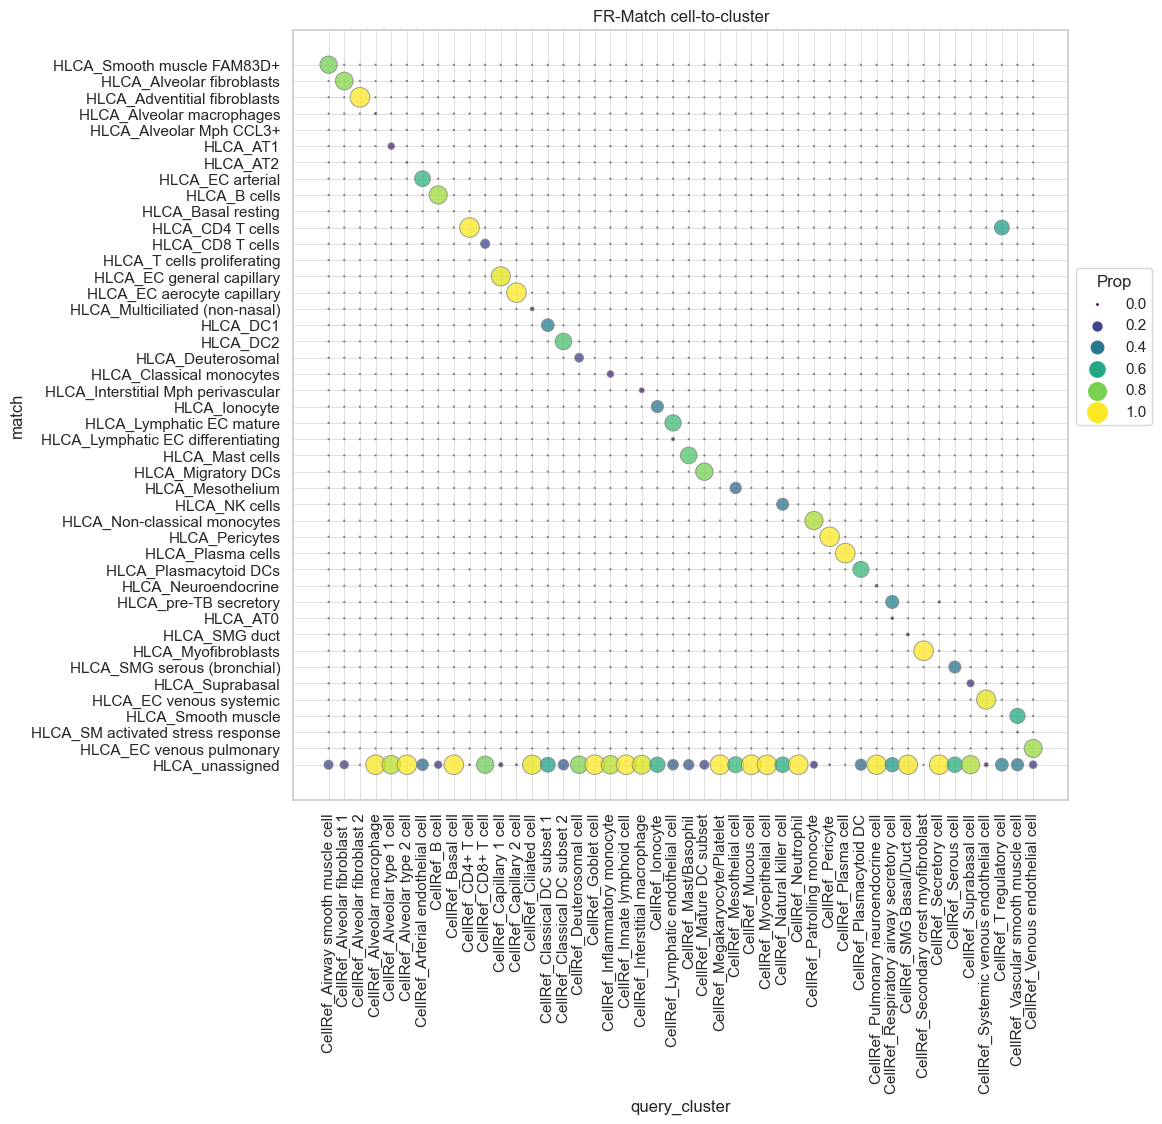

In [22]:
if not title: title = "FR-Match cell-to-cluster"
fig, (ax1) = plt.subplots(1, 1, figsize=(width, height))
sns.set_theme(style="whitegrid", rc={"grid.color": "lightgray", "grid.linewidth": 0.5})
ax = sns.scatterplot(results_7, x = "query_cluster", y = "match", hue = "Prop", size = "Prop", 
                    hue_norm = (0, 1), size_norm = (0, 1), legend = "brief", 
                    sizes = (1, 200), alpha = 0.75, linewidth = 0.7, edgecolor = "gray", 
                    palette = sns.color_palette("viridis", as_cmap=True), 
                   )
a = plt.title(title)
a = plt.xticks(rotation = 90)
a = plt.legend(title = "Prop", bbox_to_anchor = (1.0, 0.7))